# Retrieving Automatically Vector Bounding Boxes

In [3]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

## Inspecting the Vector Extent Geopackage

In [6]:
data_folder = Path('../../data')
fiona.listlayers(f'{data_folder}/nederland_admin_areas.gpkg')

['country', 'provinces', 'cities']

In [8]:
vector = gpd.read_file(f'{data_folder}/nederland_admin_areas.gpkg', layer='country')
vector = vector.to_crs('EPSG:4326')

vector.shape

(1, 4)

In [9]:
vector.head(1)

,identificatie,naam,code,geometry
0,LND6030,Nederland,6030,"MULTIPOLYGON (((4.86923 51.41179, 4.86943 51.4..."


## Visualising the Dataset

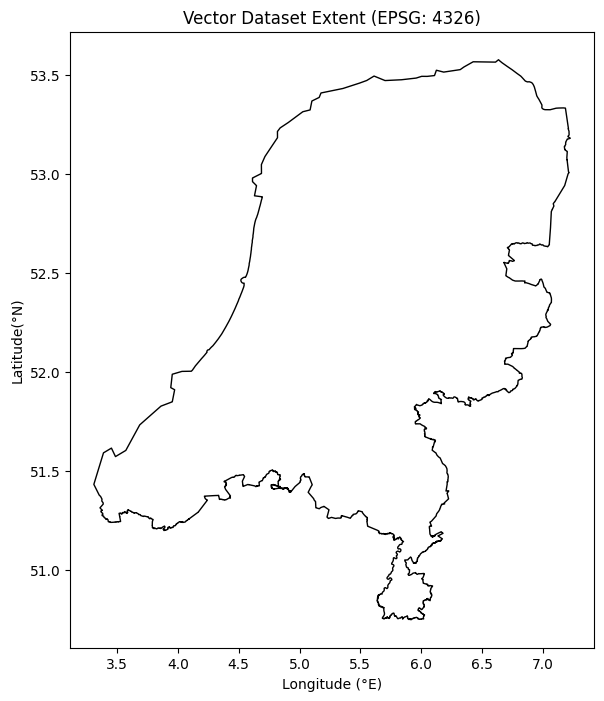

In [18]:
fig, ax = plt.subplots(figsize=(8,8))
vector.plot(ax=ax, color='none')

ax.set_title('Vector Dataset Extent (EPSG: 4326)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude(°N)')

plt.show()

## Inspecting the Raster Extent GeoPackage

In [15]:
raster = gpd.read_file(f'{data_folder}/raster_extent.gpkg')
raster.shape

(1, 11)

In [16]:
raster.head(1)

,MINX,MINY,MAXX,MAXY,CNTX,CNTY,AREA,PERIM,HEIGHT,WIDTH,geometry
0,4.436121,51.324523,6.077758,52.341355,5.256939,51.832939,1.669269,5.316938,1.016832,1.641637,"POLYGON ((4.43612 51.32452, 6.07776 51.32452, ..."


## Visualising the Dataset

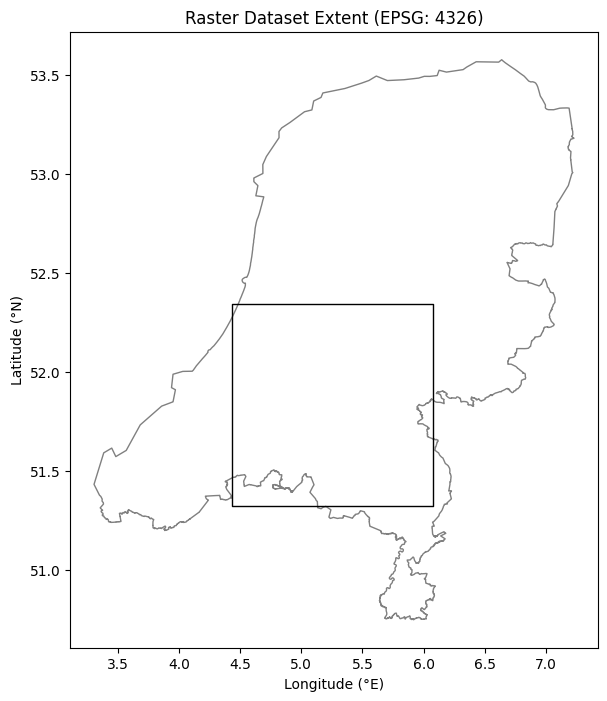

In [17]:
fig, ax = plt.subplots(figsize=(8,8))
vector.plot(ax=ax, color='none', edgecolor='gray')
raster.plot(ax=ax, color='none')

ax.set_title('Raster Dataset Extent (EPSG: 4326)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

plt.show()

## Creating the Final Subplots

In [21]:
vector_centroid = vector.geometry.centroid
raster_centroid = raster.geometry.centroid

/tmp/ipykernel_20775/1719074437.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vector_centroid = vector.geometry.centroid
/tmp/ipykernel_20775/1719074437.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  raster_centroid = raster.geometry.centroid


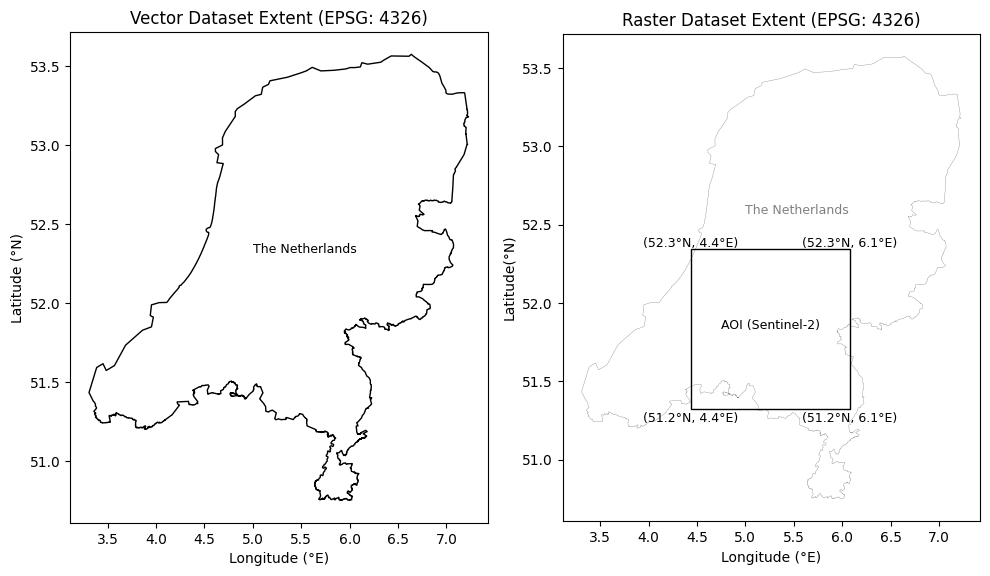

In [30]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,10))
ax = axs.flatten()

vector.plot(ax=ax[0], color='none')
ax[0].annotate(xy=(vector_centroid.x.iloc[0], vector_centroid.y.iloc[0]), text='The Netherlands', ha='center', fontsize=9)

ax[0].set_title('Vector Dataset Extent (EPSG: 4326)')
ax[0].set_xlabel('Longitude (°E)')
ax[0].set_ylabel('Latitude (°N)')

vector.plot(ax=ax[1], color='none', edgecolor='grey', linewidth=0.25)
raster.plot(ax=ax[1], color='none')

ax[1].annotate(xy=(vector_centroid.x.iloc[0], vector_centroid.y.iloc[0] + 0.25), text='The Netherlands', ha='center', fontsize=9, color='gray')
ax[1].annotate(xy=(raster_centroid.x.iloc[0], raster_centroid.y.iloc[0]), text='AOI (Sentinel-2)', ha='center', fontsize=9)

bbox = box(*raster.total_bounds)
bbox = bbox.exterior.coords[:-1]

for (x, y) in bbox:
    if (x, y) in [bbox[0], bbox[-1]]:
        y -= 0.100
    ax[1].annotate(xy=(x,y), text=f'({y:.1f}°N, {x:.1f}°E)', ha='center', va='bottom', fontsize=9)

ax[1].set_title('Raster Dataset Extent (EPSG: 4326)')
ax[1].set_xlabel('Longitude (°E)')
ax[1].set_ylabel('Latitude(°N)')

plt.tight_layout()
plt.show()